# Step 1: Generate Mask Tables for Compositing
Run this notebook FIRST before composite_cookie_choc.ipynb.
It generates the per-Gaussian, per-timestamp mask tables (.pt files) needed for compositing.

You need to run Sections A and B — one for each scene.

In [25]:
import os, time
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import torch
import numpy as np
from matplotlib import pyplot as plt
from argparse import ArgumentParser
from tqdm import tqdm
from arguments import ModelParams, PipelineParams, ModelHiddenParams
from scene import Scene, GaussianModel
from gaussian_renderer import render, render_contrastive_feature, render_segmentation, render_mask
from utils.segment_utils import get_combined_args, visualize_obj, to8b
import mmcv
from utils.params_utils import merge_hparams

%load_ext autoreload
%autoreload 2

def plot(img_list, ncols=3):
    for i, img in enumerate(img_list):
        plt.subplot(1, ncols, i+1)
        plt.imshow(img)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def load_feature_gaussians(model_path, cfg_path='./arguments/hypernerf/default.py'):
    """Load a scene in feature mode so we can access _mlp and _classifier."""
    parser = ArgumentParser()
    model_p = ModelParams(parser, sentinel=True)
    pipeline_p = PipelineParams(parser)
    hp = ModelHiddenParams(parser)
    parser.add_argument('--iteration', default=-1, type=int)
    parser.add_argument('--mode', default='feature')
    parser.add_argument('--configs', type=str, default=cfg_path)

    args = get_combined_args(parser, model_path, 'feature')
    config = mmcv.Config.fromfile(args.configs)
    args = merge_hparams(args, config)

    dataset = model_p.extract(args)
    hyperparam = hp.extract(args)
    pipeline = pipeline_p.extract(args)

    # feature mode needs object masks for gt supervision
    dataset.object_masks = True
    dataset.need_gt_masks = True

    gaussians = GaussianModel(dataset.sh_degree, 'feature', hyperparam, dataset.feature_dim)
    scene = Scene(dataset, gaussians, load_iteration=args.iteration, mode='feature')

    bg_color = [1,1,1] if dataset.white_background else [0,0,0]
    bg_color_t = torch.tensor(bg_color, dtype=torch.float32, device='cuda')
    bg_feature = torch.zeros(dataset.feature_dim, dtype=torch.float32, device='cuda')

    train_cams = list(scene.getTrainCameras())
    video_cams = list(scene.getVideoCameras())
    print(f'train views: {len(train_cams)}, video views: {len(video_cams)}')
    return gaussians, scene, pipeline, bg_color_t, bg_feature, train_cams, video_cams

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
## SECTION A: torchocolate — extract the chocolate/torch object
This mask will be used to INSERT the torchocolate object into the cookie scene.

In [26]:
CHOC_MODEL = './output/hypernerf/torchocolate'
CFG = './arguments/hypernerf/default.py'

g_choc, scene_choc, pipe_choc, bg_choc, bgf_choc, train_choc, vid_choc = \
    load_feature_gaussians(CHOC_MODEL, CFG)

print(f'Total Gaussians in torchocolate: {g_choc.get_xyz.shape[0]}')

Looking for config file in ./output/hypernerf/torchocolate/feature_cfg_args
Config file found at: ./output/hypernerf/torchocolate/feature_cfg_args
ID Encoding Dimension:  32
mode:  feature
Loading trained model at iteration 14000
load finished


174it [00:00, 85507.78it/s]

format finished
Loading Training Cameras
Loading Test Cameras
Loading Video Cameras
Deformation Net Set aabb [47.76659775 31.60019684 94.26104736] [-54.118927   -65.01464844   9.57078719]
Voxel Plane: set aabb= Parameter containing:
tensor([[ 47.7666,  31.6002,  94.2610],
        [-54.1189, -65.0146,   9.5708]])


loading model from exists./output/hypernerf/torchocolate/point_cloud/iteration_14000
train views: 174, video views: 695
Total Gaussians in torchocolate: 246117


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1389406..0.69187784].


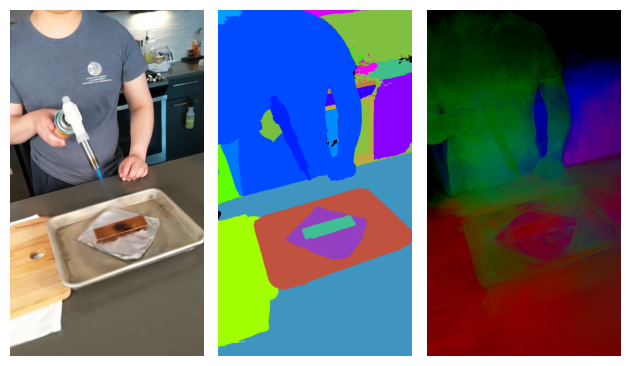

Middle image = object ID map. Note the IDs of the torch/chocolate and flame.


In [27]:
# ── Visualise the classifier's object map on a reference frame ──
# Pick a frame where the torch/chocolate is clearly visible
REF_IDX = 30  # adjust if needed
ref_view = train_choc[REF_IDX]

with torch.no_grad():
    rendering = render(ref_view, g_choc, pipe_choc, bg_choc)['render']
    img = to8b(rendering).transpose(1,2,0)

    identity_encoding = render_contrastive_feature(ref_view, g_choc, pipe_choc, bgf_choc)['render']
    logits = g_choc._classifier(identity_encoding)
    pred_obj = torch.argmax(logits, dim=0).cpu().numpy()

    from sklearn.decomposition import PCA
    ie_norm = torch.nn.functional.normalize(identity_encoding, dim=0)
    X = ie_norm.permute([1,2,0]).flatten(0,1).cpu().numpy()
    np.random.seed(6)
    pca = PCA(n_components=3)
    pca.fit(X)
    X_rgb = pca.transform(X).reshape(*identity_encoding.shape[-2:], 3)

plot([img, visualize_obj(pred_obj), X_rgb])
print('Middle image = object ID map. Note the IDs of the torch/chocolate and flame.')

In [28]:
# Print the ID at specific pixels — hover over the middle image above
# and pick row, col coordinates of the colors you want to identify

# The chocolate bar on the tray looks like it's around the red/brown region
# The torch/nozzle looks like the small colored region near top-center

sample_pixels = [
    # (row, col) — row 0 is TOP of image, col 0 is LEFT
    (400, 150),  # the red/brown tray area
    (350, 200),  # the chocolate bar
    (200, 150),  # the torch nozzle area (small colored bit near top center)
    (100, 180),  # upper body / torch handle area
    (300, 100),  # person's body
]

print("pixel (row, col) → object ID")
for r, c in sample_pixels:
    if r < pred_obj.shape[0] and c < pred_obj.shape[1]:
        print(f"  ({r:4d}, {c:4d}) → ID {pred_obj[r, c]}")

# Also print ALL IDs sorted by how many pixels they cover
unique_ids, counts = np.unique(pred_obj, return_counts=True)
print("\nAll IDs ranked by size (biggest region first):")
for cnt, uid in sorted(zip(counts, unique_ids), reverse=True)[:20]:
    print(f"  ID {uid:3d}  →  {cnt:6d} pixels")

pixel (row, col) → object ID
  ( 400,  150) → ID 1
  ( 350,  200) → ID 69
  ( 200,  150) → ID 1
  ( 100,  180) → ID 1
  ( 300,  100) → ID 1

All IDs ranked by size (biggest region first):
  ID   1  →  154006 pixels
  ID  64  →  141088 pixels
  ID  68  →   56284 pixels
  ID  57  →   44319 pixels
  ID  36  →   27785 pixels
  ID  53  →   21950 pixels
  ID  32  →   16259 pixels
  ID  69  →    7045 pixels
  ID   2  →    6473 pixels
  ID  15  →    5380 pixels
  ID  80  →    4772 pixels
  ID  46  →    4767 pixels
  ID  77  →    4182 pixels
  ID  52  →    3798 pixels
  ID  43  →    3665 pixels
  ID  70  →    3193 pixels
  ID 189  →    2154 pixels
  ID  61  →    1916 pixels
  ID   9  →    1762 pixels
  ID  79  →    1200 pixels


In [ ]:
# ── SET THESE based on what you found above ──
# From the demo_hypernerf.ipynb comments these were:
#   flame = [66, 67], chocolate = [65, 31, 77]
# But YOUR trained model may have different IDs. Use the pixel lookup above.

# IDs that correspond to the torch/chocolate itself
CHOC_OBJECT_IDS = [80, 32]   # ← UPDATE

# OPTIONAL: IDs that correspond to the plate/foil/tray under the chocolate.
# If you want the plate included in the saved mask table, add its IDs here.
PLATE_OBJECT_IDS = [32]        # ← e.g. [12, 44]

SELECTED_IDS = sorted(set(CHOC_OBJECT_IDS + PLATE_OBJECT_IDS))
selected_obj_ids_choc = torch.tensor(SELECTED_IDS).cuda()
print(f"Using IDs: {SELECTED_IDS}")

# ── Sanity check with argmax + confidence + spatial filtering ──
MIN_CONFIDENCE = 0.5          # only include Gaussians where top-class prob > this
OUTLIER_PERCENTILE = 0.95     # drop the furthest 5% of Gaussians as spatial outliers

with torch.no_grad():
    means3D = g_choc.get_xyz
    ts = torch.tensor(ref_view.time).to(means3D.device).repeat(means3D.shape[0], 1)
    ie = g_choc._mlp(means3D, ts)
    logits3d = g_choc._classifier(ie.unsqueeze(1).permute(2,0,1))
    prob3d = torch.softmax(logits3d, dim=0)

    # --- Argmax + minimum confidence (replaces old soft threshold) ---
    top_id = torch.argmax(prob3d, dim=0).squeeze()        # [N]
    top_prob = prob3d.max(dim=0).values.squeeze()          # [N]
    mask_check = torch.zeros_like(top_id, dtype=torch.bool)
    for oid in selected_obj_ids_choc:
        mask_check |= (top_id == oid) & (top_prob > MIN_CONFIDENCE)

    print(f'After argmax + confidence filter: {mask_check.sum().item()} / {means3D.shape[0]}')

    # --- Spatial outlier removal ---
    if mask_check.any():
        selected_xyz = means3D[mask_check]
        center = selected_xyz.mean(dim=0)
        dists = (selected_xyz - center).norm(dim=-1)
        cutoff = dists.quantile(OUTLIER_PERCENTILE)
        inlier = dists <= cutoff
        full_inlier = torch.zeros_like(mask_check)
        full_inlier[mask_check] = inlier
        mask_check = full_inlier
        print(f'After spatial outlier removal:   {mask_check.sum().item()} / {means3D.shape[0]}')

    seg_render = render_segmentation(ref_view, g_choc, pipe_choc, bg_choc, mask_check.bool())['render']
    seg_img = to8b(seg_render.detach()).transpose(1,2,0)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(img); plt.title('Full scene'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(seg_img); plt.title('Segmented object (argmax + spatial filter)'); plt.axis('off')
plt.tight_layout(); plt.show()
print('Adjust MIN_CONFIDENCE (higher = tighter) and OUTLIER_PERCENTILE (lower = tighter) if needed.')

In [ ]:
# ── Generate and save torchocolate mask table ──
# Uses argmax + confidence + spatial filtering (same as sanity check cell above)
interval    = 1        # use every training frame
lamb_neg    = 2
lr          = 10000

num_samples = (len(train_choc) + interval - 1) // interval
g_choc.create_mask_table(num_samples)
count = 0

print(f'Building mask table over {num_samples} timestamps...')
print(f'  MIN_CONFIDENCE={MIN_CONFIDENCE}, OUTLIER_PERCENTILE={OUTLIER_PERCENTILE}')
t0 = time.time()

for idx, view in enumerate(tqdm(train_choc)):
    if idx % interval:
        continue
    g_choc._time_map[count] = view.time

    with torch.no_grad():
        means3D = g_choc.get_xyz
        ts = torch.tensor(view.time).to(means3D.device).repeat(means3D.shape[0], 1)
        ie = g_choc._mlp(means3D, ts)
        logits3d = g_choc._classifier(ie.unsqueeze(1).permute(2,0,1))
        prob3d = torch.softmax(logits3d, dim=0)

        # --- Argmax + minimum confidence ---
        top_id = torch.argmax(prob3d, dim=0).squeeze()
        top_prob = prob3d.max(dim=0).values.squeeze()
        mask3d = torch.zeros_like(top_id, dtype=torch.bool)
        for oid in selected_obj_ids_choc:
            mask3d |= (top_id == oid) & (top_prob > MIN_CONFIDENCE)

        # --- Spatial outlier removal ---
        if mask3d.any():
            selected_xyz = means3D[mask3d]
            center = selected_xyz.mean(dim=0)
            dists = (selected_xyz - center).norm(dim=-1)
            cutoff = dists.quantile(OUTLIER_PERCENTILE)
            inlier = dists <= cutoff
            clean_mask = torch.zeros_like(mask3d)
            clean_mask[mask3d] = inlier
            mask3d = clean_mask

        g_choc._mask_table[count] = mask3d

        # Gradient-based boundary refinement
        gt_mask = (view.objects.cuda()[..., None] ==
                   selected_obj_ids_choc[None, None, :]).any(dim=-1).squeeze().int()

    tmp_mask = g_choc._mask_table[count].float()
    final_mask = tmp_mask.detach().clone().unsqueeze(-1)
    final_mask.requires_grad = True
    rendered_mask = render_mask(view, g_choc, pipe_choc, bg_choc,
                                precomputed_mask=final_mask)['mask'].squeeze()
    loss = -(gt_mask * rendered_mask).sum() + lamb_neg * ((1 - gt_mask) * rendered_mask).sum()
    loss.backward()
    grad_score = final_mask.grad.clone()
    final_mask = final_mask - lr * grad_score
    final_mask[final_mask < 0]  = 0
    final_mask[final_mask != 0] = 1
    final_mask *= tmp_mask.float().unsqueeze(-1)
    g_choc._mask_table[count] = final_mask.squeeze().bool()
    del final_mask, loss, grad_score

    count += 1

print(f'Done in {time.time()-t0:.1f}s')

# Save
save_dir = os.path.join(CHOC_MODEL, 'segment_results')
g_choc.save_mask_table(
    save_dir,
    'torchocolate',
    {
        'min_confidence': MIN_CONFIDENCE,
        'outlier_percentile': OUTLIER_PERCENTILE,
        'interval': interval,
        'lamb_neg': lamb_neg,
        'lr': lr,
        'selected_ids': SELECTED_IDS,
    },
)
print(f'Saved to {save_dir}/torchocolate.pt')

In [43]:
# ── Quick verification: render a few frames from the mask table ──
import imageio
frames = []
with torch.no_grad():
    for view in tqdm(vid_choc[:90]):   # first 3 seconds
        diff  = torch.abs(g_choc._time_map - view.time)
        index = torch.argmin(diff)
        mask  = g_choc._mask_table[index]
        r = render_segmentation(view, g_choc, pipe_choc, bg_choc, mask.bool())['render']
        frames.append(to8b(r.detach()).transpose(1,2,0))

os.makedirs('demo', exist_ok=True)
imageio.mimwrite('demo/check_torchocolate_seg.mp4', frames, fps=30)
print('Saved demo/check_torchocolate_seg.mp4 — check this looks right before proceeding.')

100%|██████████| 90/90 [00:00<00:00, 120.94it/s]
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (536, 960) to (544, 960) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved demo/check_torchocolate_seg.mp4 — check this looks right before proceeding.


---
## SECTION B: split-cookie — background (full scene, no mask needed)

For compositing, split-cookie will be used as the **background**.
We have two options:
- **Option B1** (simple): use `seg=False` in the composite notebook → renders the entire cookie scene
- **Option B2** (cleaner): remove the cookie/hand from the background and replace with the torchocolate object

Run B1 first to get compositing working, then optionally do B2 for a cleaner result.

In [44]:
# ── Option B2: generate a DELETE mask for split-cookie ──
# (Skip this cell if using Option B1 / seg=False)

COOKIE_MODEL = './output/hypernerf/split-cookie'

g_cook, scene_cook, pipe_cook, bg_cook, bgf_cook, train_cook, vid_cook = \
    load_feature_gaussians(COOKIE_MODEL, CFG)

print(f'Total Gaussians in split-cookie: {g_cook.get_xyz.shape[0]}')

Looking for config file in ./output/hypernerf/split-cookie/feature_cfg_args
Config file found at: ./output/hypernerf/split-cookie/feature_cfg_args
ID Encoding Dimension:  32
mode:  feature
Loading trained model at iteration 14000
load finished


135it [00:00, 74445.31it/s]

format finished


Loading Training Cameras
Loading Test Cameras
Loading Video Cameras
Deformation Net Set aabb [ 8.0361395  6.8197494 22.259563 ] [-7.0418544 -8.908094  11.280437 ]
Voxel Plane: set aabb= Parameter containing:
tensor([[ 8.0361,  6.8197, 22.2596],
        [-7.0419, -8.9081, 11.2804]])
loading model from exists./output/hypernerf/split-cookie/point_cloud/iteration_14000
train views: 135, video views: 539
Total Gaussians in split-cookie: 196777


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0017135..0.82266104].


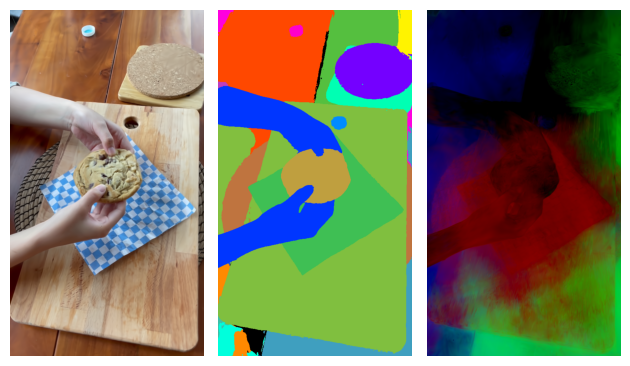

Find the IDs for cookie, hand, circle etc.


In [45]:
REF_IDX_COOK = 30
ref_view_cook = train_cook[REF_IDX_COOK]

with torch.no_grad():
    rendering_c = render(ref_view_cook, g_cook, pipe_cook, bg_cook)['render']
    img_c = to8b(rendering_c).transpose(1,2,0)

    ie_c = render_contrastive_feature(ref_view_cook, g_cook, pipe_cook, bgf_cook)['render']
    logits_c = g_cook._classifier(ie_c)
    pred_obj_c = torch.argmax(logits_c, dim=0).cpu().numpy()

    ie_norm_c = torch.nn.functional.normalize(ie_c, dim=0)
    Xc = ie_norm_c.permute([1,2,0]).flatten(0,1).cpu().numpy()
    pca_c = PCA(n_components=3); pca_c.fit(Xc)
    Xc_rgb = pca_c.transform(Xc).reshape(*ie_c.shape[-2:], 3)

plot([img_c, visualize_obj(pred_obj_c), Xc_rgb])
print('Find the IDs for cookie, hand, circle etc.')

In [46]:
# Same pixel-lookup helper for cookie scene
sample_pixels_c = [(300, 200), (350, 250), (400, 300)]
for r, c in sample_pixels_c:
    if r < pred_obj_c.shape[0] and c < pred_obj_c.shape[1]:
        print(f'pixel ({r},{c}) → object ID: {pred_obj_c[r, c]}')

unique_ids_c, counts_c = np.unique(pred_obj_c, return_counts=True)
print('\nAll object IDs:')
for uid, cnt in sorted(zip(counts_c, unique_ids_c), reverse=True):
    print(f'  ID {uid:3d}: {cnt} pixels')

pixel (300,200) → object ID: 35
pixel (350,250) → object ID: 35
pixel (400,300) → object ID: 18

All object IDs:
  ID 177831: 36 pixels
  ID 69155: 47 pixels
  ID 61986: 35 pixels
  ID 47420: 20 pixels
  ID 26632: 19 pixels
  ID 24800: 28 pixels
  ID 20827: 18 pixels
  ID 20096: 30 pixels
  ID 18638: 26 pixels
  ID 14000: 180 pixels
  ID 9723: 25 pixels
  ID 4714: 31 pixels
  ID 4450: 5 pixels
  ID 4392: 0 pixels
  ID 4363: 93 pixels
  ID 2379: 3 pixels
  ID 1281: 43 pixels
  ID 1036: 37 pixels
  ID 471: 4 pixels
  ID 336: 24 pixels
  ID  30: 1 pixels


In [ ]:
# ── SET these: IDs you want to REMOVE from the cookie background ──
# From the demo comments: cookie=18, hand=35, circle=19
# Verify with your pixel lookup above.
COOKIE_REMOVE_IDS = [18]   # ← UPDATE if needed
selected_obj_ids_cook = torch.tensor(COOKIE_REMOVE_IDS).cuda()

MIN_CONFIDENCE_COOK = 0.5
OUTLIER_PERCENTILE_COOK = 0.95

# Sanity check with argmax + confidence + spatial filtering
with torch.no_grad():
    means3D_c = g_cook.get_xyz
    ts_c = torch.tensor(ref_view_cook.time).to(means3D_c.device).repeat(means3D_c.shape[0], 1)
    ie2 = g_cook._mlp(means3D_c, ts_c)
    logits3d_c = g_cook._classifier(ie2.unsqueeze(1).permute(2,0,1))
    prob3d_c = torch.softmax(logits3d_c, dim=0)

    # --- Argmax + minimum confidence ---
    top_id_c = torch.argmax(prob3d_c, dim=0).squeeze()
    top_prob_c = prob3d_c.max(dim=0).values.squeeze()
    mask_chk = torch.zeros_like(top_id_c, dtype=torch.bool)
    for oid in selected_obj_ids_cook:
        mask_chk |= (top_id_c == oid) & (top_prob_c > MIN_CONFIDENCE_COOK)

    print(f'After argmax + confidence filter: {mask_chk.sum().item()} / {means3D_c.shape[0]}')

    # --- Spatial outlier removal ---
    if mask_chk.any():
        selected_xyz_c = means3D_c[mask_chk]
        center_c = selected_xyz_c.mean(dim=0)
        dists_c = (selected_xyz_c - center_c).norm(dim=-1)
        cutoff_c = dists_c.quantile(OUTLIER_PERCENTILE_COOK)
        inlier_c = dists_c <= cutoff_c
        clean_mask_c = torch.zeros_like(mask_chk)
        clean_mask_c[mask_chk] = inlier_c
        mask_chk = clean_mask_c
        print(f'After spatial outlier removal:   {mask_chk.sum().item()} / {means3D_c.shape[0]}')

    # render with those IDs REMOVED (invert the mask)
    del_render = render_segmentation(ref_view_cook, g_cook, pipe_cook, bg_cook,
                                      (~mask_chk).bool())['render']
    del_img = to8b(del_render.detach()).transpose(1,2,0)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(img_c); plt.title('Full cookie scene'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(del_img); plt.title('Cookie/hand removed'); plt.axis('off')
plt.tight_layout(); plt.show()

In [ ]:
# ── Generate and save split-cookie DELETE mask table ──
# Uses argmax + confidence + spatial filtering (same as sanity check cell above)
interval_c = 1

num_samples_c = (len(train_cook) + interval_c - 1) // interval_c
g_cook.create_mask_table(num_samples_c)
count_c = 0

print(f'Building delete mask table for split-cookie over {num_samples_c} timestamps...')
print(f'  MIN_CONFIDENCE={MIN_CONFIDENCE_COOK}, OUTLIER_PERCENTILE={OUTLIER_PERCENTILE_COOK}')
t0 = time.time()

with torch.no_grad():
    for idx, view in enumerate(tqdm(train_cook)):
        if idx % interval_c:
            continue
        g_cook._time_map[count_c] = view.time

        means3D_c = g_cook.get_xyz
        ts_c = torch.tensor(view.time).to(means3D_c.device).repeat(means3D_c.shape[0], 1)
        ie_c2 = g_cook._mlp(means3D_c, ts_c)
        logits3d_c2 = g_cook._classifier(ie_c2.unsqueeze(1).permute(2,0,1))
        prob3d_c2 = torch.softmax(logits3d_c2, dim=0)

        # --- Argmax + minimum confidence ---
        top_id_c2 = torch.argmax(prob3d_c2, dim=0).squeeze()
        top_prob_c2 = prob3d_c2.max(dim=0).values.squeeze()
        mask3d_c = torch.zeros_like(top_id_c2, dtype=torch.bool)
        for oid in selected_obj_ids_cook:
            mask3d_c |= (top_id_c2 == oid) & (top_prob_c2 > MIN_CONFIDENCE_COOK)

        # --- Spatial outlier removal ---
        if mask3d_c.any():
            sel_xyz = means3D_c[mask3d_c]
            ctr = sel_xyz.mean(dim=0)
            ds = (sel_xyz - ctr).norm(dim=-1)
            cut = ds.quantile(OUTLIER_PERCENTILE_COOK)
            inl = ds <= cut
            clean = torch.zeros_like(mask3d_c)
            clean[mask3d_c] = inl
            mask3d_c = clean

        # INVERT: keep everything EXCEPT the cookie/hand
        g_cook._mask_table[count_c] = ~mask3d_c
        count_c += 1

print(f'Done in {time.time()-t0:.1f}s')

save_dir_c = os.path.join(COOKIE_MODEL, 'segment_results')
g_cook.save_mask_table(save_dir_c, 'split-cookie',
                       {'min_confidence': MIN_CONFIDENCE_COOK,
                        'outlier_percentile': OUTLIER_PERCENTILE_COOK,
                        'interval': interval_c,
                        'removed_ids': COOKIE_REMOVE_IDS})
print(f'Saved to {save_dir_c}/split-cookie.pt')

In [49]:
# ── Final check: verify both .pt files exist ──
files_to_check = [
    './output/hypernerf/torchocolate/segment_results/torchocolate.pt',
    './output/hypernerf/split-cookie/segment_results/split-cookie.pt',
]
for f in files_to_check:
    exists = os.path.exists(f)
    size   = os.path.getsize(f) // 1024 if exists else 0
    print(f'  {"✓" if exists else "✗"} {f}  ({size} KB)')

print('\nIf both show ✓ you are ready to run composite_cookie_choc.ipynb')

  ✓ ./output/hypernerf/torchocolate/segment_results/torchocolate.pt  (41822 KB)
  ✓ ./output/hypernerf/split-cookie/segment_results/split-cookie.pt  (25943 KB)

If both show ✓ you are ready to run composite_cookie_choc.ipynb
